# CSI 5170 - Project #1
**Creator**: Janis Miroll, janismiroll@oakland.edu

**Project**: Develop and train a deep neural network (DNN) using PyTorch to classify images from the 
CIFAR-10 dataset. Perform a comprehensive ablation study to assess the impact of various 
methods and hyperparameters on model performance. To deepen your understanding of neural 
networks, you’ll have to manually implement it without using PyTorch’s built-in functions

## Description 

### 1. Model Architecture

Your model must include the following layers, which you’ll have to manually implement without using PyTorch’s built-in functions. 
1) At least one fully-connected layer 
2) At least one convolutional layer 
3) At least one ReLU activation layer 
4) Softmax layer (for output classification) 

### 2. Performance requirement:

The final test accuracy of your model should exceed 75% on the CIFAR-10 dataset. The higher, the better. You will get extra credit if the accuracy exceeds 80%. 

### 3. Regularization Techniques: 


The following regularization methods should be implemented without using PyTorch’s built-in functions. 
1) L2 regularization 
2) Dropout 

The above techniques should be implemented and evaluated in the ablation study, but not necessarily used in your model training for getting a good test accuracy. 
Optional: You can use some data augmentation methods (e.g., random cropping, flipping, etc.). 

### 4. Optimization Techniques: 


The following optimization methods should be implemented without using PyTorch’s built-in functions. 
1) Gradient descent with momentum 
2) Adam 
3) Cosine learning rate decay 
4) One additional learning rate decay algorithm 

The above techniques should be implemented and evaluated in the ablation study, but not necessarily used in your model training for getting a good test accuracy. 

### 5. Evaluation Metrics & Visualizations: 


 
Plot the figures about the following metrics of the model achieving over 75% accuracy. 
1) Training accuracy over each epoch 
2) Test accuracy over each epoch 
3) Cost over each iteration

 ### 6. Ablation Study:

Conduct a thorough ablation study to analyze the effects of different methods and hyperparameters on model performance. You are required to study and report the effects on the test accuracy (required), and the following metrics (optional), including convergence speed, training accuracy, cost values, etc. 
 
Findings or insights should be discussed. Virtualization is preferred, like figures of accuracy over epoch. Convergence speed refers to the rate at which a model’s training process reduces the loss function and approaches an optimal or acceptable performance on the training data. 
 
Your ablation study should include, at a minimum, the following aspects (the more aspects, the better). To save training time, for the ablation study, you do not need to train the model for the entire epochs; you can only train the model for a few epochs—just enough to observe hyperparameter differences. 
1) Effect of at least two different learning rate decay algorithms 
2) Effect of different regularization methods, at least including L2 regularization and 
Dropout 
3) Effect of lambda of L2 regularization 
4) Effect of different optimization algorithms, at least including gradient descent with 
momentum and Adam 
5) Effect of beta1 and beta2 of Adam 
 
Ablation study is a crucial element in research papers, providing valuable insights into the 
contribution of each component of a model or system.  About how to conduct ablation study, 
refer to the Section of Ablation Study in the following papers. You can refer to more papers 
published in the top AI conferences, e.g., NeurIPS, ICML, ICLR, CVPR, ICCV, ECCV, AISTATS.

#### Allowed PyTorch functions
The  following  built-in  data  loader  function,  data  augmentation  functions,  pooling  layers,  and 
normalization layers are allowed to use: 
- torch.utils.data.DataLoader 
- torchvision.transforms.RandomCrop 
- torchvision.transforms.RandomHorizontalFlip 
- torchvision.transforms.RandomVerticalFlip 
- torchvision.transforms.ColorJitter 
- torchvision.transforms.RandomResizedCrop 
- Pooling Layers 
    - torch.nn.functional.max_pool1d 
    - torch.nn.functional.max_pool2d 
    - torch.nn.functional.max_pool3d 
    - torch.nn.functional.avg_pool1d 
    - torch.nn.functional.avg_pool2d 
    - torch.nn.functional.avg_pool3d 
    - torch.nn.functional.adaptive_max_pool2d 
    - torch.nn.functional.adaptive_avg_pool2d 
- Normalization Layers 
    - torch.nn.functional.batch_norm 
    - torch.nn.functional.instance_norm 
    - torch.nn.functional.layer_norm 
    - torch.nn.functional.group_norm 

## Implementation

In [ ]:
# Uncomment if not already installed in kernel
#!pip install torch torchvision numpy matplotlib

In [1]:
import torch
import torch.nn.functional as F
import numpy as np

print(torch.__version__)
torch.manual_seed(42)

2.10.0


In [2]:
device = torch.device("mps" if torch.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


1) Activation Layers

In [3]:
# ReLu
def ReLu(Z):
    return Z * (Z > 0)

In [4]:
# Softmax
def softmax(Z):
    shifted_Z = Z - torch.max(Z, dim = 0, keepdim = True).values
    exp = torch.exp(shifted_Z)
    return exp / torch.sum(exp, dim = 0, keepdim = True)

In [5]:
# Sigmoid
def sigmoid(Z):
    return 1 / (1 + torch.exp(-Z))

2) Loss function

In [6]:
def cross_entropy_loss(A, y):
    batch_m = y.shape[0]
    log_probs = torch.log(A[y, torch.arange(batch_m)] + 1e-15)
    return - torch.sum(log_probs) / batch_m

In [7]:
def reg_L2(lambda_reg, y, *weights):
    batch_m = y.shape[0]
    penalty = 0
    for W in weights:
        penalty += torch.sum(W ** 2)
    return (lambda_reg / (2 * batch_m)) * penalty

3. Optimization: GD, GD with momentum, RMSprop, Adam

In [8]:
def optimizer_step(params, opt_state, alpha, optimizer="sgd", beta1=0.9, beta2=0.99, eps=1e-8):
    """Updates params in-place. Works for sgd / momentum / rmsprop and adam"""
    opt_state["t"] += 1
    t = opt_state["t"]
    with torch.no_grad():
        for i, p in enumerate(params):
            grad = p.grad
            v = opt_state[i]["v"]
            s = opt_state[i]["s"]
            
            if optimizer == "sgd":
                p.data -= alpha * grad
            elif optimizer == "momentum":
                v.mul_(beta1).add_((1 - beta1) * grad)
                p.data -= alpha * v
            elif optimizer == "rmsprop":
                s.mul_(beta2).add_((1 - beta2) * grad * grad)
                p.data -= alpha * grad / (s.sqrt() + eps)
            elif optimizer == "adam":
                v.mul_(beta1).add_((1 - beta1) * grad)
                s.mul_(beta2).add_((1 - beta2) * grad * grad)
                # Bias correction
                v_cor = v / (1 - (beta1 ** t))
                s_cor = s / (1 - (beta2 ** t))
                p.data -= alpha * v_cor / (s_cor.sqrt() + eps)
            p.grad.zero_()
    

4. Optimization: Learning rate decay

In [9]:
def learning_rate_decay(initial_lr, epoch, epochs, decay = "None"):
    """Updates Learning rate given the Decay method. Works for None, step, cosine, linear, inv_sqrt"""
    if decay == "None":
        return initial_lr
    elif decay == "step":
        if epoch < epochs // 3:
            return initial_lr
        elif epoch < 2 * epochs // 3:
            return 0.1 * initial_lr
        else:
            return 0.01 * initial_lr
    elif decay == "cosine":
        return 0.5 * initial_lr * (1 + torch.cos(torch.tensor(epoch * torch.pi / epochs)))
    elif decay == "linear":
        return max(initial_lr * (1 - (epoch / (epochs - 1))), 1e-6)
    elif decay == "inv_sqrt":
        return initial_lr / (epoch + 1) ** 0.5

5. Conv Layer Activation

In [10]:
def conv_forward(X, weight, b, pad, s):
    """
    Inputs:
        X: (N, C, H, W)             - batch of N images, C channels, spatial HxW
        weight: (Cp, C, Fh, Fw)     - Cp filters, each of shape CxFhxFw
        b: (Cp,)                    - One bias per output filter
        pad: int                    - zero-padding
        s: int             - stride
    """
    N, _ , H, W = X.shape
    Cp, _, Fh , Fw = weight.shape

    X_padded = F.pad(X, (pad, pad, pad, pad), value = 0) # X_padded: (N, C, H + 2*pad, W + 2*pad)
    X_col = F.unfold(X_padded, kernel_size = (Fh, Fw), stride = s) # X_col: (N, C*Fh*Fw , H_out * W_out)
    H_out = (H + 2*pad - Fh) // s + 1 # H_out: int
    W_out = (W + 2*pad - Fw) // s + 1 # W_out: int
    # L: H_out * W_out
    out = weight.flatten(1) @ X_col + b[None, :, None] # (Cp, C*Fh*Fw) @ (N, C*Fh*Fw, L) + (1, Cp, 1) → (N, Cp, L)

    return out.view(N, Cp, H_out, W_out) # (N, Cp, H_out, W_out)

### Load Cifar10 dataset

In [11]:
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader

In [12]:
# Augment dataset with torchvision.transforms
transforms = v2.Compose([
    v2.RandomCrop(32, padding = 4),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.ColorJitter(brightness = 0.5, hue = 0.3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [13]:
train_set = datasets.CIFAR10(
    root='./data',
    train = True,
    download = True,
    transform = transforms)
train_loader = DataLoader(train_set, batch_size = 128, shuffle = True)

In [14]:
test_set = datasets.CIFAR10(
    root = './data/test',
    train = False,
    download = True,
    transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale = True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
)
test_loader = DataLoader(test_set, batch_size=100, shuffle=False)

### Define Model Parameters & Hyperparameters

In [19]:
### Model Architecture

# Convolutional Layers
n_H1 = 32 # 32 pixels wide
n_W1 = 32 # 32 pixels wide
n_C1 = 3 # RGB Picture, hence 3 channels
f1 = 5 # Filter 1 size will be 5 x 5 x n_C1
n_C1p = 32 # Number of Filters in layer 1, n_C1prime
pad1 = 2 # Padding
s1 = 1 # Stride

n_H2 = ((n_H1 + 2 * pad1 - f1) // s1 + 1) // 2 # Pooling reduces the size of the image by a factor of 2
n_W2 = ((n_W1 + 2 * pad1 - f1) // s1 + 1) // 2
n_C2 = n_C1p
f2 = 3 # Filter 2 size
n_C2p = 64 # Number of Filters in layer 2, n_C2prime
pad2 = 1 # Padding
s2 = 1 # Stride

n_H3 = ((n_H2 + 2 * pad2 - f2) // s2 + 1) // 2 # Pooling reduces the size of the image by a factor of 2
n_W3 = ((n_W2 + 2 * pad2 - f2) // s2 + 1) // 2
n_C3 = n_C2p
f3 = 3 # Filter 2 size
n_C3p = 128 # Number of Filters in layer 3, n_C3prime
pad3 = 1 # Padding
s3 = 1 # Stride


# Fully Connected Layers
#n_x = 32 * 32 * 3 # Input size: 32 x 32 RGB images flattened to a 1D array
n_H3p = ((n_H3 + 2 * pad3 - f3) / s3 + 1) // 2 # Pooling
n_W3p = ((n_W3 + 2 * pad3 - f3) / s3 + 1) // 2
n_h3p = int(n_H3p * n_W3p * n_C3p) # Number of outputs from Conv layer to a 1D array
n_h4 = 256 # Number of neurons in the fourth hidden layer (FC)
n_output = 10 # 10 output classes for CIFAR10

### General Hyperparameters
learning_rate = 0.001
epochs = 50

### Regularization
regularization = True
if regularization:
    lambda_ = 0.01
dropout = True
drop_p4 = 0.1

### Optimizer
optimizer = "adam" # pick from "sgd", "momentum", "rmsprop" and "adam"
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
lr_decay = "cosine" # pick from "None", "step", "cosine", "linear", "inv_sqrt"


### Define Train_model function

In [22]:
def train_model(
    epochs = 50,
    learning_rate = 0.001,
    optimizer = "adam",
    beta1 = 0.9,
    beta2 = 0.999,
    epsilon = 1e-8,
    lr_decay = "None",
    regularization = False,
    lambda_ = 0.01,
    dropout = False,
    drop_p = 0.1
):

    torch.manual_seed(123)
    # Conv layers
    W1 = torch.nn.Parameter(
        torch.randn(n_C1p, n_C1, f1, f1, dtype=torch.float32, device = device) * np.sqrt(2 / (n_C1 * f1 * f1))
        )
    b1 = torch.nn.Parameter(
        torch.zeros((n_C1p,), dtype=torch.float32, device = device)
        )
    W2 = torch.nn.Parameter(
        torch.randn(n_C2p, n_C2, f2, f2, dtype=torch.float32, device = device) * np.sqrt(2 / (n_C2 * f2 * f2))
        )
    b2 = torch.nn.Parameter(
        torch.zeros((n_C2p,), dtype=torch.float32, device = device)
        )
    W3 = torch.nn.Parameter(
        torch.randn(n_C3p, n_C3, f3, f3, dtype=torch.float32, device = device) * np.sqrt(2 / (n_C3 * f3 * f3))
        )
    b3 = torch.nn.Parameter(
        torch.zeros((n_C3p,), dtype=torch.float32, device = device)
        )

    # FC Layers
    W4 = torch.nn.Parameter(
        torch.randn(n_h4, n_h3p, dtype=torch.float32, device = device) * np.sqrt(2 / n_h3p)
        )
    b4 = torch.nn.Parameter(
        torch.zeros((n_h4, 1), dtype=torch.float32, device = device)
        )

    W5 = torch.nn.Parameter(
        torch.randn(n_output, n_h4, dtype=torch.float32, device = device) * np.sqrt(2 / n_h4)
        )
    b5 = torch.nn.Parameter(
        torch.zeros((n_output, 1), dtype=torch.float32, device = device)
        )

    params = [W1, b1, W2, b2, W3, b3, W4, b4, W5, b5]


    cost_values = []
    train_acc_values = []
    test_acc_values = []

    ### Initialize optimizer
    opt_state = {}
    for i, p in enumerate(params):
        opt_state[i] = {
            "v": torch.zeros_like(p),
            "s": torch.zeros_like(p)
        }
    opt_state["t"] = 0

    for epoch in range(epochs):
        print(f"Epoch: {epoch}")

        # Training Accuracy
        correct_train = 0
        total_train = 0

        for data in train_loader:
            inputs, labels = data
            
            X = inputs.to(device)
            y = labels.to(device)

            ### Forward propagation
            
            # Conv Layers

            Z1 = conv_forward(X, W1, b1, pad1, s1)
            A1 = ReLu(Z1)
            A1 = F.max_pool2d(A1, 2) # 32x32 -> 32x16x16
            
            Z2 = conv_forward(A1, W2, b2, pad2, s2)
            A2 = ReLu(Z2)
            A2 = F.max_pool2d(A2, 2) # 64x16 -> 64x8x8

            Z3 = conv_forward(A2, W3, b3, pad3, s3)
            A3 = ReLu(Z3)
            A3 = F.max_pool2d(A3, 2) # 128x8 -> 128x4x4


            A3 = A3.view(-1, n_h3p).T # Flatten and transpose before transition to FC layers

            # FC Layers

            Z4 = torch.mm(W4, A3) + b4
            A4 = ReLu(Z4)
            if dropout:
                mask2 = (torch.rand_like(A4) > drop_p).float()
                A4 = (A4 * mask2) / (1 - drop_p)

            Z5 = torch.mm(W5, A4) + b5
            A5 = softmax(Z5)

            # Log correct predictions
            predictions = torch.argmax(A5, dim = 0)
            correct_train += torch.sum(predictions == y).item()
            total_train += y.size(0)

            # Compute the cross-entropy loss
            J = cross_entropy_loss(A5, y)

            # Add L2 regularization
            if regularization:
                J += reg_L2(lambda_, y, W1, W2, W3, W4, W5)

            # Backward propagation (calculate gradients)
            J.backward()

            # Update weights and biases using gradient descent
            lr = learning_rate_decay(learning_rate, epoch, epochs, lr_decay)
            optimizer_step(params, opt_state, lr,
                optimizer = optimizer,
                beta1 = beta1,
                beta2 = beta2,
                eps = epsilon)

            cost_values.append(J.item())
        
        train_acc = correct_train / total_train
        train_acc_values.append(train_acc)

        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for data in test_loader:
                inputs, labels = data
                X = inputs.to(device)
                y = labels.to(device)

                Z1 = conv_forward(X, W1, b1, pad1, s1)
                A1 = ReLu(Z1)
                A1 = F.max_pool2d(A1, 2)
                Z2 = conv_forward(A1, W2, b2, pad2, s2)
                A2 = ReLu(Z2)
                A2 = F.max_pool2d(A2, 2)
                Z3 = conv_forward(A2, W3, b3, pad3, s3)
                A3 = ReLu(Z3)
                A3 = F.max_pool2d(A3, 2)
                
                A3 = A3.view(-1, n_h3p).T


                Z4 = torch.mm(W4, A3) + b4
                A4 = ReLu(Z4)
                Z5 = torch.mm(W5, A4) + b5
                A5 = softmax(Z5)

                predictions = torch.argmax(A5, dim = 0)
                correct_test += torch.sum(predictions == y).item()
                total_test += y.size(0)
        test_acc = correct_test / total_test
        test_acc_values.append(test_acc)
        print(f"Train accuracy: {train_acc}\nTest. Accuracy: {test_acc}")
    return cost_values, train_acc_values, test_acc_values, params

## Ablation Study

In [ ]:
import matplotlib.pyplot as plt # For evaluation
def plot_results(results, title):
    """Plot accuracy and cost curves for multilpe experiment variations.
    Args:
        results: dict of {label: (cost_values, train_acc_values, test_acc_values)}
        title: String
    """

    colors = plt.cm.tab10.colors

    # Create a figure with two side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for i, (label, (cost, train_acc, test_acc)) in enumerate(results.items()):
        color = colors[i % len(colors)]
        epochs = range(len(train_acc))

        ax1.plot(epochs, train_acc, color = color, linestyle = '-', label = f'{label} train')
        ax1.plot(epochs, test_acc, color = color, linestyle = '--', label = f'{label} test')

        ax2.plot(range(len(cost)), cost, color = color, label = label)
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Accuracy")
    ax1.set_title("Train & Test Accuracy")
    ax1.legend()
    ax1.grid(True)

    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Cost")
    ax2.set_title("Cost over Iterations")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(title + ".pdf")
    plt.show()


### Optimizers

In [ ]:
adam_cost, adam_train_acc, adam_test_acc, _ = train_model(epochs = 15, optimizer = "adam")

In [ ]:
momentum_cost, momentum_train_acc, momentum_test_acc, _ = train_model(epochs = 15, optimizer = "momentum")

In [ ]:
rms_cost, rms_train_acc, rms_test_acc, _ = train_model(epochs = 15, optimizer = "rmsprop", beta2 = 0.9)

In [ ]:
sgd_cost, sgd_train_acc, sgd_test_acc, _ = train_model(epochs = 15, optimizer = "sgd")

In [ ]:
plot_results({
    "Adam": (adam_cost, adam_train_acc, adam_test_acc),
    "Momentum": (momentum_cost, momentum_train_acc, momentum_test_acc),
    "RMSProp": (rms_cost, rms_train_acc, rms_test_acc),
    "SGD": (sgd_cost, sgd_train_acc, sgd_test_acc)
}, title = "Optimizer Comparison")

--> Adam optimizer performs by far the best and hence will be chosen as baseline going forward.

### L2 Lambda

In [ ]:
results = {}
for lam in [0.0001, 0.001, 0.01, 0.1]:
    c, tr, te, _ = train_model(epochs = 15, lambda_ = lam, regularization=True)
    results[f"lambda = {lam}"] = (c, tr, te)
plot_results(results, title = "L2 Lambda Comparison")

### Dropout vs L2 Regularization

In [ ]:
dropout_cost, dropout_train_acc, dropout_test_acc, _ = train_model(epochs = 15, dropout = True)
regL2_cost, regL2_train_acc, regL2_test_acc, _ = train_model(epochs = 15, regularization = True)
noReg_cost, noReg_train_acc, noReg_test_acc, _ = train_model(epochs = 15, dropout = False, regularization = False)
both_cost, both_train_acc, both_test_acc, _ = train_model(epochs = 15, dropout = True, regularization = True)

In [ ]:
plot_results({
    "Dropout": (dropout_cost, dropout_train_acc, dropout_test_acc),
    "L2 Regularization": (regL2_cost, regL2_train_acc, regL2_test_acc),
    "None": (noReg_cost, noReg_train_acc, noReg_test_acc),
    "Both": (both_cost, both_train_acc, both_test_acc),
}, title = "Regularization Comparison")

### Adam Optimizer: Beta1 & Beta 2 effects

In [ ]:
results = {}
for b1 in [0.0, 0.5, 0.9, 0.95, 0.99]:
    c, tr, te, _ = train_model(epochs = 15, optimizer="adam", beta1 = b1, beta2 = 0.999)
    results[f"beta1 = {b1}"] = (c, tr, te)
plot_results(results, title = "Effect of Adam beta1 with beta2 = 0.999")

In [ ]:
results = {}
for b2 in [0.9, 0.99, 0.999, 0.9999]:
    c, tr, te, _ = train_model(epochs = 15, optimizer="adam", beta1 = 0.9, beta2 = b2)
    results[f"beta2 = {b2}"] = (c, tr, te)
plot_results(results, title = "Effect of Adam beta2 with beta1 = 0.9")

### Learning Rate Decay algo's

In [ ]:
results = {}
for lr_dc in ["None", "step", "cosine", "linear", "inv_sqrt"]:
    c, tr, te, _ = train_model(epochs = 15, lr_decay = lr_dc)
    results[lr_dc] = (c, tr, te)
plot_results(results, title = "Learning Rate Decay Comparison")

## Final 3 models based on ablation study

In [ ]:
# Option 1
cost_1, train_acc_1, test_acc_1, params1 = train_model(
    epochs = 100,
    learning_rate = 0.001,
    optimizer = "adam",
    beta1 = 0.9,
    beta2 = 0.999,
    epsilon=1e-8,
    lr_decay = "cosine",
    regularization=True,
    dropout = True,
    lambda_=0.001,
    drop_p=0.1
)

In [ ]:
# Option 2 - No dropout
cost_2, train_acc_2, test_acc_2, params2 = train_model(
    epochs = 100,
    learning_rate = 0.001,
    optimizer = "adam",
    beta1 = 0.9,
    beta2 = 0.999,
    epsilon=1e-8,
    lr_decay = "cosine",
    regularization=True,
    dropout = False,
    lambda_=0.001,
    drop_p=0.1
)

In [ ]:
# Option 3 - L2 Lambda
cost_3, train_acc_3, test_acc_3, params3 = train_model(
    epochs = 100,
    learning_rate = 0.001,
    optimizer = "adam",
    beta1 = 0.9,
    beta2 = 0.999,
    epsilon=1e-8,
    lr_decay = "cosine",
    regularization=True,
    dropout = True,
    lambda_=0.01,
    drop_p=0.1
)

Epoch: 0
Train accuracy: 0.31892
Test. Accuracy: 0.4775
Epoch: 1
Train accuracy: 0.48522
Test. Accuracy: 0.5889
Epoch: 2
Train accuracy: 0.55242
Test. Accuracy: 0.6358
Epoch: 3
Train accuracy: 0.5928
Test. Accuracy: 0.663
Epoch: 4
Train accuracy: 0.61944
Test. Accuracy: 0.6794
Epoch: 5
Train accuracy: 0.64462
Test. Accuracy: 0.6995
Epoch: 6
Train accuracy: 0.66
Test. Accuracy: 0.7137
Epoch: 7
Train accuracy: 0.67382
Test. Accuracy: 0.7234
Epoch: 8
Train accuracy: 0.6867
Test. Accuracy: 0.7196
Epoch: 9
Train accuracy: 0.69812
Test. Accuracy: 0.7372
Epoch: 10
Train accuracy: 0.70584
Test. Accuracy: 0.7446
Epoch: 11
Train accuracy: 0.71552
Test. Accuracy: 0.7419
Epoch: 12
Train accuracy: 0.72292
Test. Accuracy: 0.761
Epoch: 13
Train accuracy: 0.73078
Test. Accuracy: 0.755
Epoch: 14
Train accuracy: 0.73206
Test. Accuracy: 0.7646
Epoch: 15
Train accuracy: 0.74254
Test. Accuracy: 0.7726
Epoch: 16
Train accuracy: 0.74674
Test. Accuracy: 0.7723
Epoch: 17
Train accuracy: 0.74996
Test. Accuracy:

In [ ]:
plot_results({
    "Baseline": (cost_1, train_acc_1, test_acc_1),
    "No Dropout": (cost_2, train_acc_2, test_acc_2),
    "Lambda_0.01": (cost_3, train_acc_3, test_acc_3),
}, title = "Long Run Comparison")

## Optional: Saved models from long runs

In [ ]:
#torch.save({
#    'W1': params1[0], 'b1': params1[1],
#    'W2': params1[2], 'b2': params1[3],
#    'W3': params1[4], 'b3': params1[5],
#    'W4': params1[6], 'b4': params1[7],
#    'W5': params1[8], 'b5': params1[9],
#}, "model_a.pth")
#
#torch.save({
#    'W1': params2[0], 'b1': params2[1],
#    'W2': params2[2], 'b2': params2[3],
#    'W3': params2[4], 'b3': params2[5],
#    'W4': params2[6], 'b4': params2[7],
#    'W5': params2[8], 'b5': params2[9],
#}, "model_b.pth")

torch.save({
    'W1': params3[0], 'b1': params3[1],
    'W2': params3[2], 'b2': params3[3],
    'W3': params3[4], 'b3': params3[5],
    'W4': params3[6], 'b4': params3[7],
    'W5': params3[8], 'b5': params3[9],
}, "model_c.pth")


NameError: name 'params1' is not defined

## Predict a Single Image (Presentation Demo)

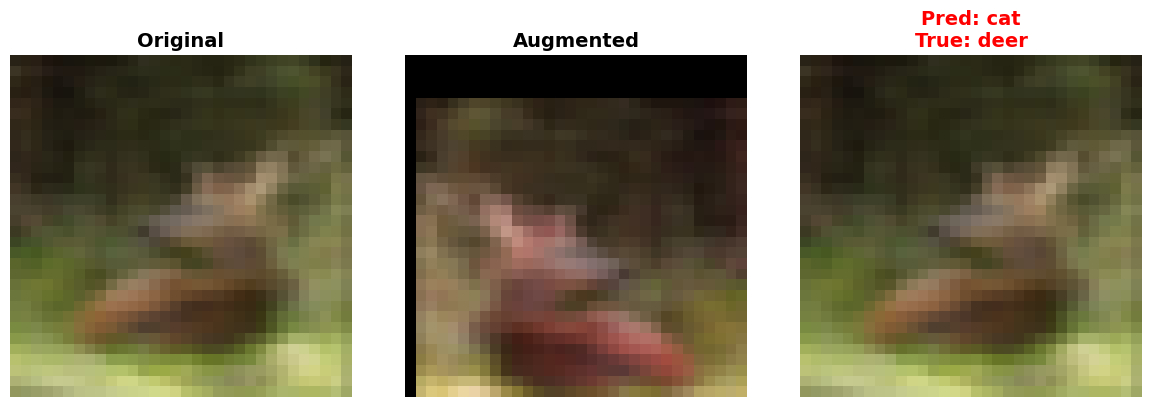

Saved as prediction_demo.png


In [ ]:
# Show original image, augmented image, and model prediction
import matplotlib.pyplot as plt
import random

classes = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

# Load Model C weights from checkpoint
checkpoint = torch.load("model_c.pth", map_location=device, weights_only=True)
W1  = checkpoint["W1"]
b1_ = checkpoint["b1"]
W2  = checkpoint["W2"]
b2_ = checkpoint["b2"]
W3  = checkpoint["W3"]
b3_ = checkpoint["b3"]
W4  = checkpoint["W4"]
b4_ = checkpoint["b4"]
W5  = checkpoint["W5"]
b5_ = checkpoint["b5"]

# 1) Original image (no transforms at all)
raw_set = datasets.CIFAR10(root="./data/test", train=False, download=False,
                           transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]))

idx = random.randint(0, len(raw_set) - 1)
raw_img, true_label = raw_set[idx]

# 2) Augmented image (same transforms used during training)
aug_transform = v2.Compose([
    v2.RandomCrop(32, padding=4),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(brightness=0.5, hue=0.3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
aug_set = datasets.CIFAR10(root="./data/test", train=False, download=False, transform=aug_transform)
aug_img, _ = aug_set[idx]  # same index

# 3) Normalize and run forward pass
norm_transform = v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
img_normalized = norm_transform(raw_img).unsqueeze(0).to(device)

Z1 = conv_forward(img_normalized, W1, b1_, pad1, s1)
A1 = F.max_pool2d(ReLu(Z1), 2)
Z2 = conv_forward(A1, W2, b2_, pad2, s2)
A2 = F.max_pool2d(ReLu(Z2), 2)
Z3 = conv_forward(A2, W3, b3_, pad3, s3)
A3 = F.max_pool2d(ReLu(Z3), 2)
A3 = A3.view(-1, n_h3p).T
Z4 = torch.mm(W4, A3) + b4_
A4 = ReLu(Z4)
Z5 = torch.mm(W5, A4) + b5_
A5 = softmax(Z5)

predicted_label = torch.argmax(A5, dim=0).item()
correct = predicted_label == true_label

# Plot all three panels
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(raw_img.permute(1, 2, 0), interpolation='nearest')
axes[0].set_title("Original", fontsize=14, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title("Augmented", fontsize=14, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(raw_img.permute(1, 2, 0))
color = "green" if correct else "red"
axes[2].set_title(f"Pred: {classes[predicted_label]}\nTrue: {classes[true_label]}",
                  fontsize=14, fontweight="bold", color=color)
axes[2].axis("off")

plt.tight_layout()
plt.savefig("prediction_demo.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved as prediction_demo.png")


In [ ]:
# Show original image, augmented image, and model prediction
import matplotlib.pyplot as plt
import random

classes = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

# Load Model C weights from checkpoint
checkpoint = torch.load("model_c.pth", map_location=device, weights_only=True)
W1  = checkpoint["W1"]
b1_ = checkpoint["b1"]
W2  = checkpoint["W2"]
b2_ = checkpoint["b2"]
W3  = checkpoint["W3"]
b3_ = checkpoint["b3"]
W4  = checkpoint["W4"]
b4_ = checkpoint["b4"]
W5  = checkpoint["W5"]
b5_ = checkpoint["b5"]

# 1) Original image (no transforms)
raw_set = datasets.CIFAR10(root="./data/test", train=False, download=False,
                           transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]))

idx = random.randint(0, len(raw_set) - 1)
raw_img, true_label = raw_set[idx]

# 2) Augmented image (same transforms used during training)
aug_transform = v2.Compose([
    v2.RandomCrop(32, padding=4),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(brightness=0.5, hue=0.3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
aug_set = datasets.CIFAR10(root="./data/test", train=False, download=False, transform=aug_transform)
aug_img, _ = aug_set[idx]

# 3) Normalize and run forward pass
norm_transform = v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
img_normalized = norm_transform(raw_img).unsqueeze(0).to(device)

Z1 = conv_forward(img_normalized, W1, b1_, pad1, s1)
A1 = F.max_pool2d(ReLu(Z1), 2)
Z2 = conv_forward(A1, W2, b2_, pad2, s2)
A2 = F.max_pool2d(ReLu(Z2), 2)
Z3 = conv_forward(A2, W3, b3_, pad3, s3)
A3 = F.max_pool2d(ReLu(Z3), 2)
A3 = A3.view(-1, n_h3p).T
Z4 = torch.mm(W4, A3) + b4_
A4 = ReLu(Z4)
Z5 = torch.mm(W5, A4) + b5_
A5 = softmax(Z5)

predicted_label = torch.argmax(A5, dim=0).item()
correct = predicted_label == true_label

# Plot — small figure so 32x32 images are not overly stretched
fig, axes = plt.subplots(1, 3, figsize=(6, 2.5))

axes[0].imshow(raw_img.permute(1, 2, 0), interpolation='lanczos')
axes[0].set_title("Original", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(aug_img.permute(1, 2, 0).clamp(0, 1), interpolation='lanczos')
axes[1].set_title("Augmented", fontsize=12, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(raw_img.permute(1, 2, 0), interpolation='lanczos')
color = "green" if correct else "red"
pred_text = f"Pred: {classes[predicted_label]}"
actual_text = f"True: {classes[true_label]}"
axes[2].set_title(pred_text + "\n" + actual_text,
                  fontsize=12, fontweight="bold", color=color)
axes[2].axis("off")

plt.tight_layout()
plt.savefig("prediction_demo.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved as prediction_demo.png")
